# Phase 5 DoD — persona depth + the full validation dashboard

**Spike:** *what minimum persona content prevents identity collapse over N ticks?* **DoD:** the full R14–17 validation dashboard running against a **null-model baseline**.

**Design — one controlled contrast.** Two arms run under the *same* topology, seed, dynamics, ids, order, temperature, and seed memories. They differ in **one thing only**: whether each persona carries value/disposition anchors (R7).

- **thick** — the hand-authored NYC cast (`personas_nyc.NYC_CAST`): value/disposition-anchored identities.
- **null** — the thin `NULL_PERSONA` (byte-identical to the P0–4 resident) with the *same* memories. This is the **R16 null-model baseline**: persona content removed, everything else held.

Holding the memories constant isolates *persona content* from *memory content* — P0–4 got their diversity from memory over a thin resident, so the question here is what the identity layer adds on top.

**The engine lives in `src/polis`; this notebook only imports down and measures.** Deterministic coverage of every metric is in `tests/test_metrics.py`, `tests/test_drift.py`, `tests/test_persona.py`. Instruments used: `metrics.divergence_trajectory` / `divergence_summary` (R14/R15/R16), `metrics.action_space_adequacy` (R27), `drift.capture_baseline` / `probe_drift` (R8).

**R27 is read FIRST (§1).** A degenerate action space (all-abstain, single-stance, parroted wording) caps observable divergence in a way the null baseline won't catch — so adequacy is checked before any convergence number is trusted.

In [1]:
import os
from collections import Counter
from dataclasses import replace

import numpy as np
import pandas as pd
from plotnine import (aes, geom_col, geom_line, geom_point, facet_wrap, ggplot,
                      labs, position_dodge, scale_x_continuous, theme_minimal, ylim)

from polis import metrics
from polis.agent import Agent
from polis.drift import capture_baseline, probe_drift
from polis.embeddings import EmbeddingModel
from polis.llm import LLMClient, LLMError
from polis.memory_seeds import build_store
from polis.personas_nyc import NULL_PERSONA, NYC_CAST
from polis.questions import DST_OPTIONS, DST_QUESTION
from polis.runlog import RunLog
from polis.scheduler import SchedulerConfig
from polis.simulation import DynamicsConfig, Population, Simulation
from polis.topology import SmallWorld

In [2]:
# --- config: edit and re-run downward ---
N_COPIES = 2                 # each of the 6 thick personas -> N_COPIES agents (N = 6 * N_COPIES)
TICKS = 5                    # sparse topology -> a legible convergence curve (P4: full-conn collapsed by tick 1)
CONCURRENCY = 8              # in-flight-request cap (R5), reused from P3
MAX_RETRIES = 4              # decode retries/backoff — absorbs the occasional Qwen3 whitespace blob
SEED = 1                    # seeds the graph and the run
SUPPORT = len(DST_OPTIONS)   # normalise entropy against the full option set
CLUSTER_THRESHOLD = 0.15     # cosine-distance threshold for metrics.cluster_count (recorded per call, R17)
DATA_CSV = '../../data/phase5_persona_validation.csv'
DRIFT_CSV = '../../data/phase5_drift.csv'
DB_DIR = '.'                 # per-arm SQLite logs beside this notebook
N_AGENTS = 6 * N_COPIES

STANCE_SHORT = {DST_OPTIONS[0]: 'perm. DST', DST_OPTIONS[1]: 'perm. standard',
                DST_OPTIONS[2]: 'keep switching', DST_OPTIONS[3]: 'no preference'}

In [3]:
client = LLMClient()
embedder = EmbeddingModel()

def build_arm(thick: bool) -> Population:
    """One population arm. Both arms share ids, order, temperature, and seed memories;
    they differ ONLY in whether the persona carries value/disposition anchors (R7).
    thick=False is the R16 null-model baseline (persona content removed)."""
    agents = []
    for copy in range(N_COPIES):
        for ps in NYC_CAST:
            pid = f'{ps.persona.id}_{copy}'
            if thick:
                persona = replace(ps.persona, id=pid)
            else:  # null: thin identity, but matched temperature + the same memories
                persona = replace(NULL_PERSONA, id=pid, temperature=ps.persona.temperature)
            store = build_store(embedder, list(ps.memories))
            agents.append(Agent(persona, client, embedder=embedder, memory=store))
    return Population(agents)

TOPOLOGY = SmallWorld(k=4, p=0.2, seed=SEED)
print('model:', client.config.model, '| agents:', N_AGENTS, '| ticks:', TICKS)
print('topology:', TOPOLOGY.to_config())
print('thick personas:', [ps.persona.id for ps in NYC_CAST])

model: qwen/qwen3-32b | agents: 12 | ticks: 5
topology: {'name': 'small_world', 'k': 4, 'p': 0.2, 'seed': 1}
thick personas: ['nurse_bx', 'parent_si', 'runner_man', 'owner_bk', 'student_bk', 'teacher_qns']


## Run both arms

Each arm captures its **R8 baseline voice** (each agent's tick-0 answer on the topic, `remember=False` so measuring doesn't perturb memory) *before* the run, runs `TICKS` ticks, then re-probes for **endpoint drift** = movement from each agent's own baseline. Same graph and seed for both arms. The persona endpoint occasionally returns a schema-invalid blob; decides absorb it via `MAX_RETRIES`, and the drift probe retries then skips a persistently-flaky agent (a diagnostic tolerates a missed probe).

In [4]:
def run_arm(name, thick):
    db = os.path.join(DB_DIR, f'phase5_{name}.db')
    if os.path.exists(db):
        os.remove(db)
    pop = build_arm(thick)
    baselines = capture_baseline(pop.agents, DST_QUESTION)          # R8 tick-0 voice
    sim = Simulation(pop, topology=TOPOLOGY, logger=RunLog.open(db),
                     dynamics=DynamicsConfig(seed=SEED),
                     scheduler_config=SchedulerConfig(max_concurrency=CONCURRENCY, max_retries=MAX_RETRIES))
    run = sim.run(TICKS)
    drift = probe_drift(pop.agents, DST_QUESTION, baselines)        # R8 endpoint drift
    return sim, run, drift

sim_thick, run_thick, drift_thick = run_arm('thick', thick=True)
sim_null, run_null, drift_null = run_arm('null', thick=False)
for nm, r in [('thick', run_thick), ('null', run_null)]:
    assert r.throughput['failures'] == 0, f'{nm}: a decide failed'
    print(f"{nm:>5}: {r.throughput['n_calls']} decides, {r.throughput['failures']} failures, "
          f"{r.throughput['total_tokens']} tokens")

C:\Users\Ryan R\Documents\DS_Projects_Local\AS-Technical-Task\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 15800.90it/s]

thick: 60 decides, 0 failures, 45085 tokens
 null: 60 decides, 0 failures, 35826 tokens


## 1. R27 — action-space adequacy (read this FIRST)

Before trusting any divergence number: is the SPEAK/ABSTAIN space actually being exercised? `abstain_rate` near 1, `stance_coverage` near 0, or low `utterance_uniqueness` would mean a low divergence reading is an artifact of the action-space ceiling, not genuine consensus (ADR 0008/0014). Any `flags` here gate the interpretation of §2–§4.

In [5]:
adeq_rows = []
for nm, run in [('thick', run_thick), ('null', run_null)]:
    a = metrics.action_space_adequacy(run, stances=DST_OPTIONS, embedder=embedder,
                                      threshold=CLUSTER_THRESHOLD)
    adeq_rows.append({'arm': nm, 'n_speak': a['n_speak'], 'abstain_rate': a['abstain_rate'],
                      'stances_used': a['distinct_stances_used'], 'stance_coverage': a['stance_coverage'],
                      'utt_uniqueness': a['utterance_uniqueness'], 'utt_dispersion': a.get('utterance_dispersion'),
                      'flags': ','.join(a['flags']) or '—'})
    disp = a.get('utterance_dispersion')
    print(f"{nm:>5}: abstain {a['abstain_rate']:.2f} | stances {a['distinct_stances_used']}/{len(DST_OPTIONS)} "
          f"| utt-uniq {a['utterance_uniqueness']:.2f} | utt-disp {disp if disp is None else round(disp, 3)} "
          f"| flags {a['flags'] or '—'}")
pd.DataFrame(adeq_rows)

thick: abstain 0.00 | stances 2/4 | utt-uniq 1.00 | utt-disp 0.245 | flags —
 null: abstain 0.00 | stances 2/4 | utt-uniq 0.97 | utt-disp 0.185 | flags —


,arm,n_speak,abstain_rate,stances_used,stance_coverage,utt_uniqueness,utt_dispersion,flags
0,thick,60,0.0,2,0.5,1.000000,0.244817,—
1,null,60,0.0,2,0.5,0.966667,0.185035,—


## 2. The validation dashboard — divergence trajectory, both axes (R14/R15)

`metrics.divergence_trajectory` gives one row per tick per arm carrying **both** the categorical read (dominant-share / entropy over discrete stances) and the **embedding read** (pairwise cosine dispersion + cluster count over the SPEAK *utterances*). The embedding axis catches within-stance wording homogenization the stance tally is blind to. Diverging thick-vs-null curves are the persona layer changing the collapse path.

In [6]:
traj_rows = []
for nm, run in [('thick', run_thick), ('null', run_null)]:
    for r in metrics.divergence_trajectory(run, embedder, support=SUPPORT, threshold=CLUSTER_THRESHOLD):
        traj_rows.append({'arm': nm, **r})
traj_df = pd.DataFrame(traj_rows)
os.makedirs(os.path.dirname(DATA_CSV), exist_ok=True)
traj_df.to_csv(DATA_CSV, index=False)
traj_df[['arm','tick','dominant_share','entropy','pairwise_dispersion','cluster_count','n_utterances']]

,arm,tick,dominant_share,entropy,pairwise_dispersion,cluster_count,n_utterances
0,thick,0,0.583333,0.489934,0.277380,8,12
1,thick,1,0.666667,0.459148,0.257530,11,12
2,thick,2,0.666667,0.459148,0.250498,9,12
3,thick,3,0.833333,0.325011,0.254446,8,12
4,thick,4,1.000000,0.000000,0.204494,8,12
5,null,0,0.833333,0.325011,0.224194,5,12
6,null,1,0.833333,0.325011,0.193925,3,12
7,null,2,1.000000,0.000000,0.175907,2,12
8,null,3,1.000000,0.000000,0.154283,3,12
9,null,4,1.000000,0.000000,0.120864,1,12


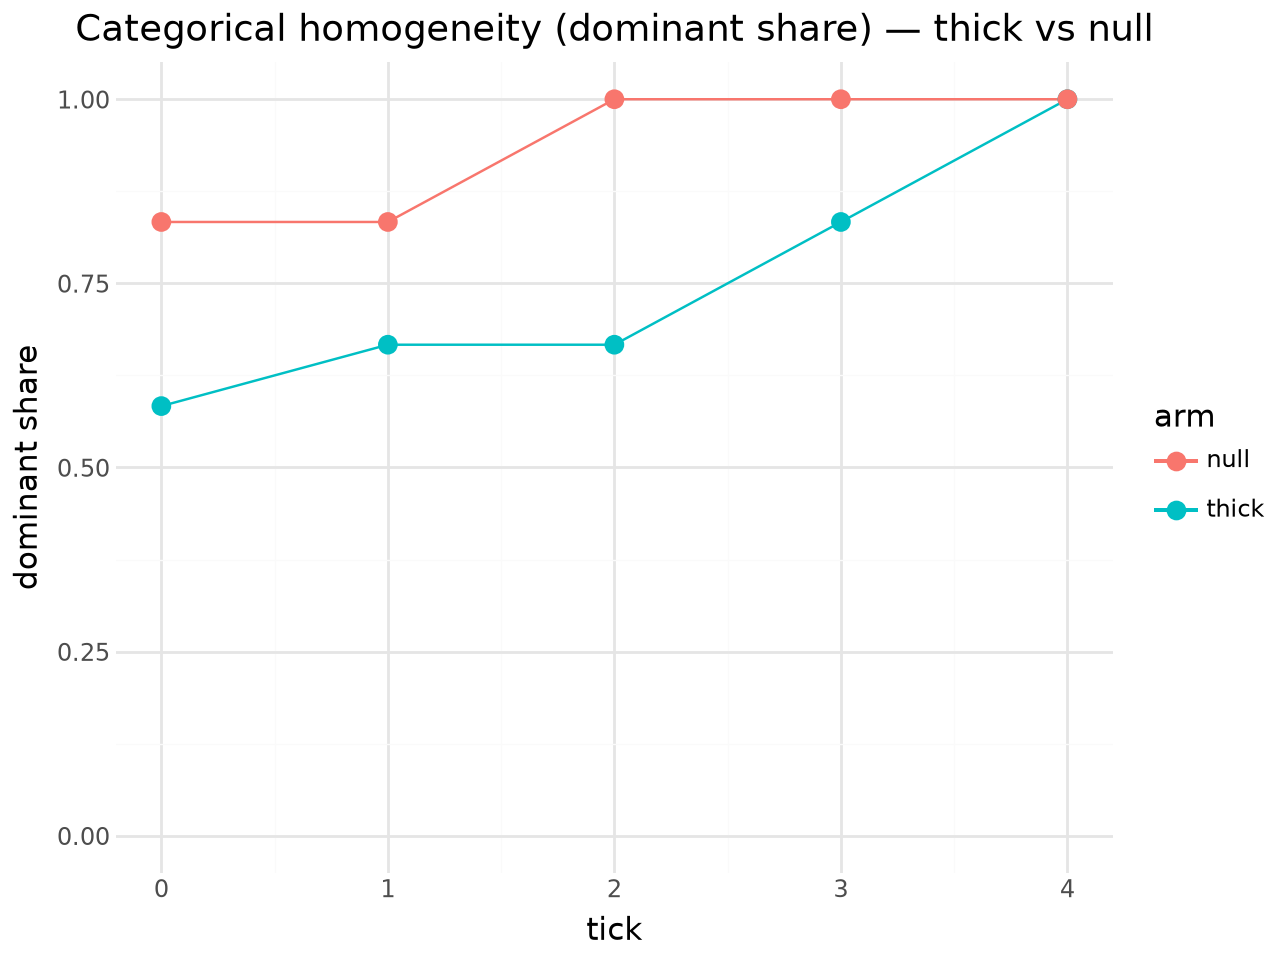

In [7]:
(ggplot(traj_df, aes('tick', 'dominant_share', color='arm'))
 + geom_line() + geom_point(size=3)
 + scale_x_continuous(breaks=list(range(TICKS))) + ylim(0, 1)
 + labs(title='Categorical homogeneity (dominant share) — thick vs null',
        x='tick', y='dominant share', color='arm')
 + theme_minimal())

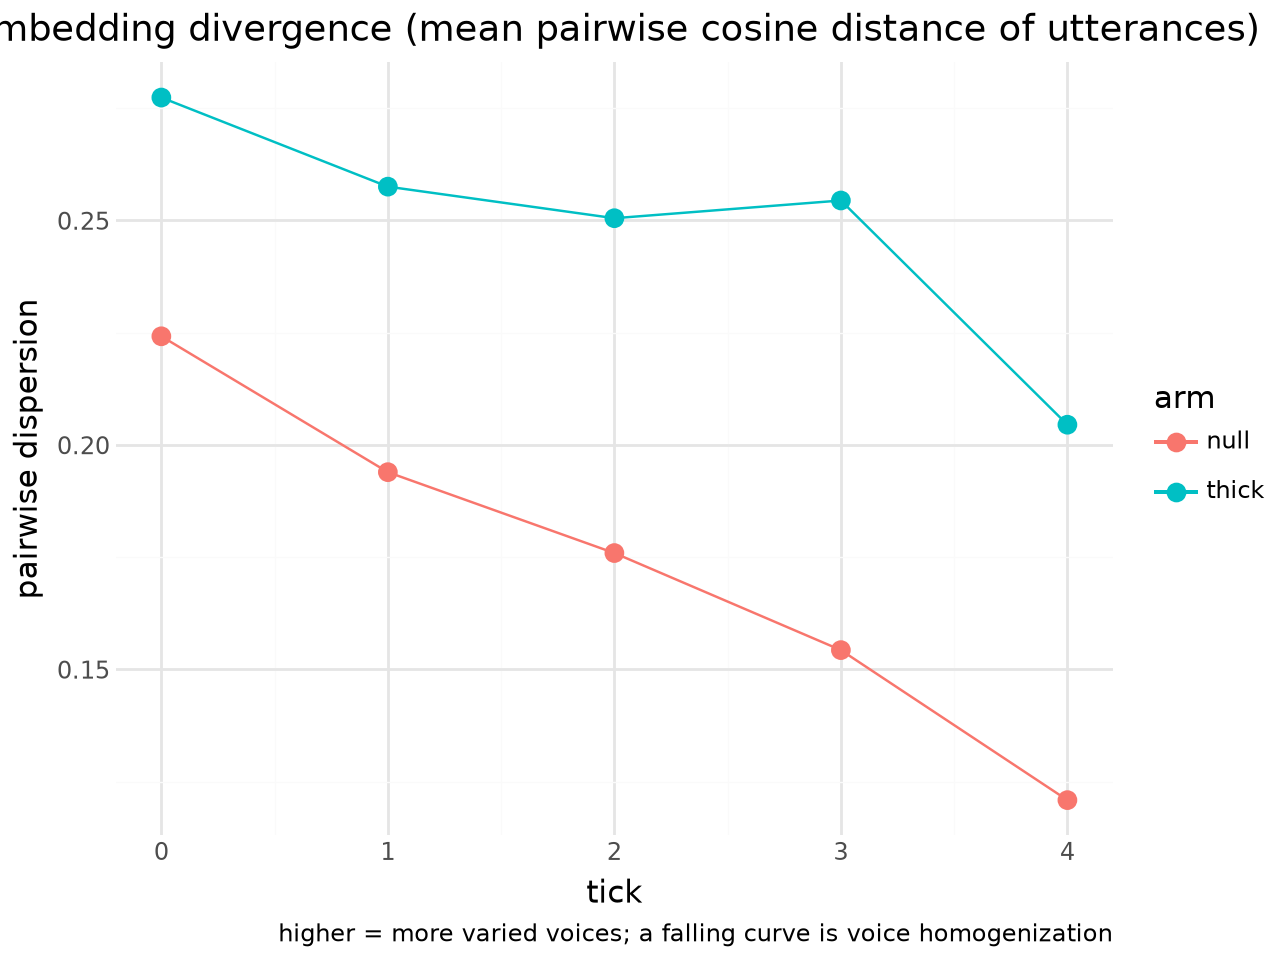

In [8]:
(ggplot(traj_df, aes('tick', 'pairwise_dispersion', color='arm'))
 + geom_line() + geom_point(size=3)
 + scale_x_continuous(breaks=list(range(TICKS)))
 + labs(title='Embedding divergence (mean pairwise cosine distance of utterances)',
        x='tick', y='pairwise dispersion', color='arm',
        caption='higher = more varied voices; a falling curve is voice homogenization')
 + theme_minimal())

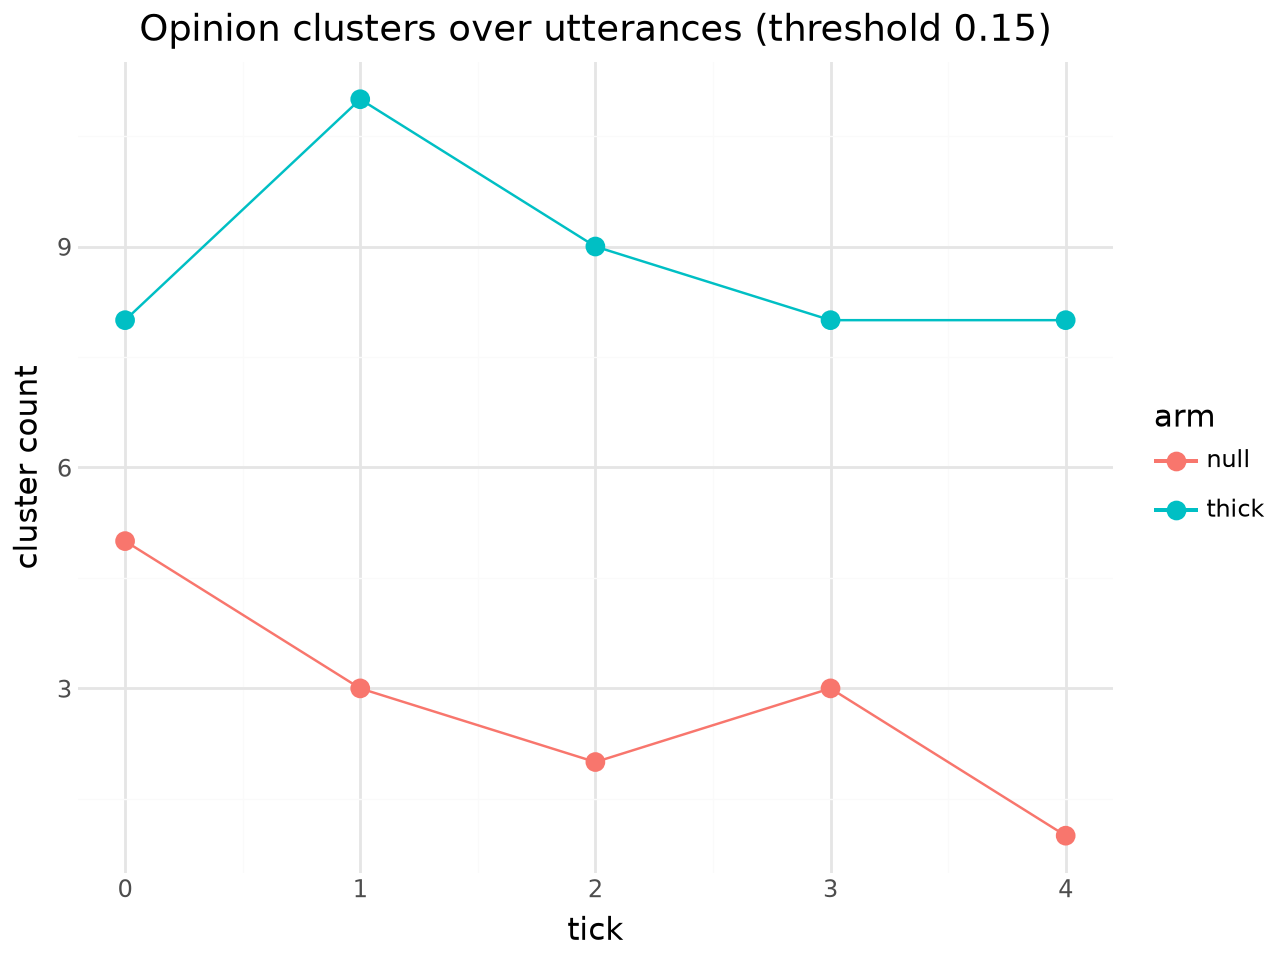

In [9]:
(ggplot(traj_df, aes('tick', 'cluster_count', color='arm'))
 + geom_line() + geom_point(size=3)
 + scale_x_continuous(breaks=list(range(TICKS)))
 + labs(title=f'Opinion clusters over utterances (threshold {CLUSTER_THRESHOLD})',
        x='tick', y='cluster count', color='arm')
 + theme_minimal())

## 3. R16 endpoint summary — thick vs the null-model baseline

`metrics.divergence_summary` bundles the endpoint of each arm on both axes. The comparison *is* the R16 test: how much of the endpoint (dis)homogeneity is attributable to the **persona layer**, with memory / topology / dynamics held identical.

In [10]:
sum_rows = []
for nm, run in [('thick', run_thick), ('null', run_null)]:
    s = metrics.divergence_summary(run, embedder, support=SUPPORT, threshold=CLUSTER_THRESHOLD)
    sum_rows.append({'arm': nm, 'dominant_share': s['dominant_share'], 'distinct': s['distinct'],
                     'entropy': s['entropy'], 'pairwise_dispersion': s['pairwise_dispersion'],
                     'cluster_count': s['cluster_count'], 'n_utterances': s['n_utterances']})
summary = pd.DataFrame(sum_rows)
summary

,arm,dominant_share,distinct,entropy,pairwise_dispersion,cluster_count,n_utterances
0,thick,1.0,1,0.0,0.204494,8,12
1,null,1.0,1,0.0,0.120864,1,12


## 4. R8 — persona strength / identity drift (baseline → endpoint)

Per agent: `drift_from_baseline` = cosine distance of its endpoint voice from its own tick-0 voice (how far it moved off its anchor); `distance_to_centroid` = distance from the population's mean endpoint voice (small-across-all = collective collapse into one voice, the R9 signal). If persona depth resists collapse (R7), the **thick** arm should show *lower* mean drift and *larger* centroid distances than the **null** arm.

In [11]:
drift_rows = []
for nm, drift in [('thick', drift_thick), ('null', drift_null)]:
    for d in drift:
        drift_rows.append({'arm': nm, 'agent_id': d.agent_id,
                           'drift_from_baseline': d.drift_from_baseline,
                           'distance_to_centroid': d.distance_to_centroid})
drift_df = pd.DataFrame(drift_rows)
drift_df.to_csv(DRIFT_CSV, index=False)
print('probes returned (of', N_AGENTS, 'per arm):',
      dict(drift_df.groupby('arm')['agent_id'].count()))
print(drift_df.groupby('arm')[['drift_from_baseline', 'distance_to_centroid']].agg(['mean', 'std']))
drift_df.groupby('arm')[['drift_from_baseline', 'distance_to_centroid']].mean()

probes returned (of 12 per arm): {'null': np.int64(12), 'thick': np.int64(12)}
      drift_from_baseline           distance_to_centroid          
                     mean       std                 mean       std
arm                                                               
null             0.191347  0.065733             0.086512  0.049418
thick            0.127263  0.047294             0.074982  0.024921


,drift_from_baseline,distance_to_centroid
arm,,
null,0.191347,0.086512
thick,0.127263,0.074982


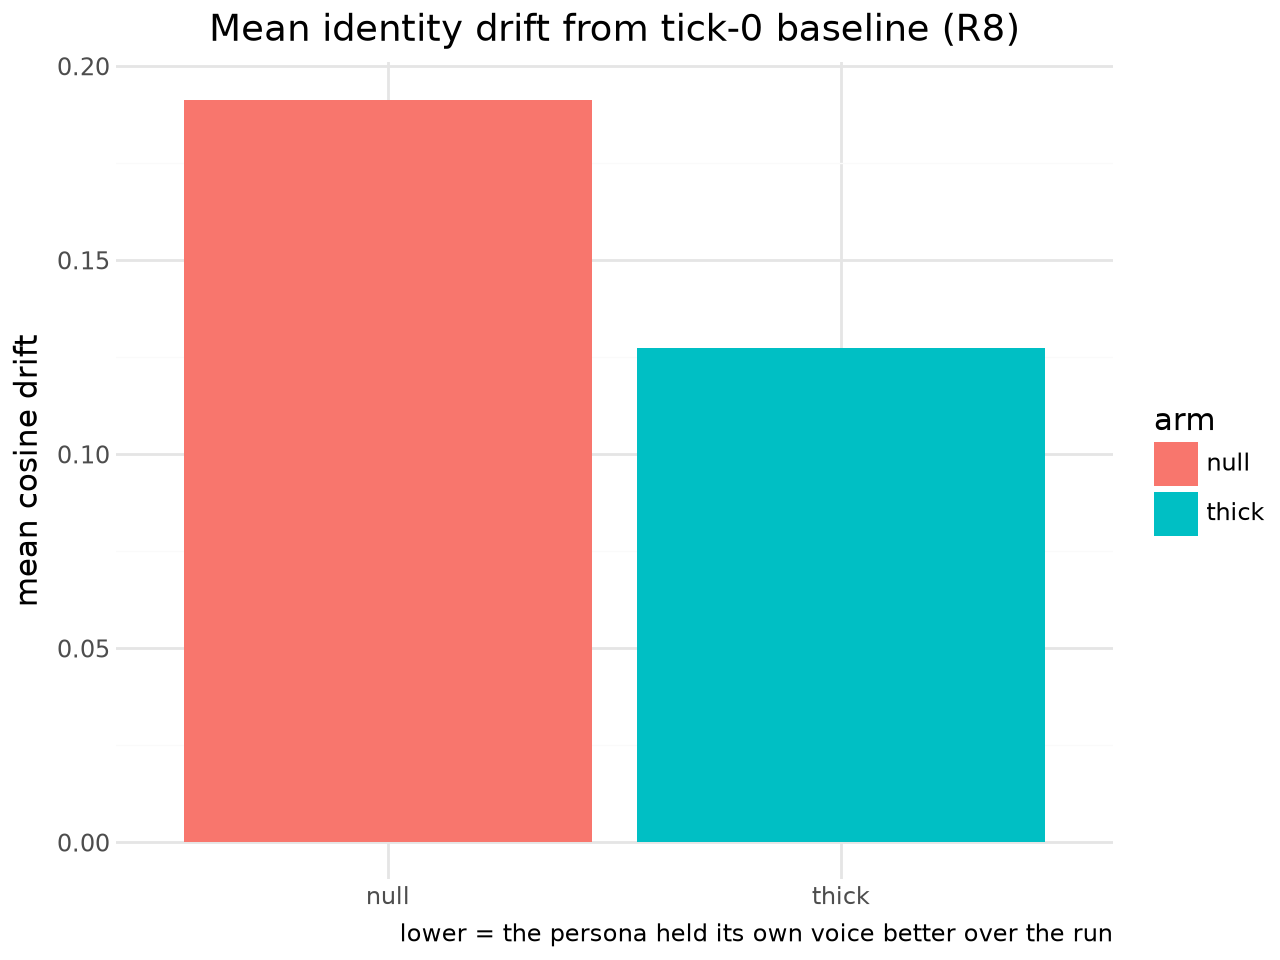

In [12]:
(ggplot(drift_df, aes('arm', 'drift_from_baseline', fill='arm'))
 + geom_col(stat='summary', fun_y=np.mean)
 + labs(title='Mean identity drift from tick-0 baseline (R8)',
        x='', y='mean cosine drift', fill='arm',
        caption='lower = the persona held its own voice better over the run')
 + theme_minimal())

## 5. Endpoint survey (R18 confirmation, in the deliverable's own units)

`population.survey` is the headline Layer-5 op (LangGraph fan-out). One survey per arm as an endpoint confirmation the log-derived metrics agree with a direct poll of the live population; responses write back per R19. Best-effort: if the endpoint hiccups on a survey call it is skipped (the query layer's own retry/skip resilience is a P7 survey-subsystem item).

In [13]:
surv_rows = []
for nm, sim in [('thick', sim_thick), ('null', sim_null)]:
    try:
        survey = sim.population.survey(DST_QUESTION)
    except LLMError as e:
        print(f"{nm:>5}: survey skipped (endpoint hiccup: {e})")
        continue
    c = Counter(a['choice'] for a in survey)
    h = metrics.homogeneity(c, support=SUPPORT)
    print(f"{nm:>5}: survey dom_share {h['dominant_share']:.2f} | entropy {h['entropy']:.2f} "
          f"| top {STANCE_SHORT.get(h['dominant_stance'], h['dominant_stance'])}")
    for choice, n in c.items():
        surv_rows.append({'arm': nm, 'stance': STANCE_SHORT.get(choice, choice), 'n': n})
sim_thick.log.close(); sim_null.log.close()
survey_df = pd.DataFrame(surv_rows)
survey_df

thick: survey skipped (endpoint hiccup: No valid survey_answer after 2 tries; last='{  \t\t\t\t\t\t\t \t\t\t\t\t\t  \n\t\t\t\t\t\t\t \t   \t\t\t\t\t\t\t \t  \t\t\t\t\t\t\t \t   \n\t\t\t\t\t\t\t \t   \n\t\t\t\t\t\t\t \t  \t\t\t\t\t\t\t \t   \n\t\t\t\t\t\t\t \t   \n\t\t\t\t\t\t\t \t   \n\t\t\t\t\t\t\t \t   \n\t\t\t\t\t\t\t \t   \n\t\t\t\t\t\t\t \t   \n\t\t\t\t\t\t\t \t   \n\t\t\t\t\t\t\t \t   \n\t\t\t\t\t\t\t \t   \n\t\t\t\t\t\t\t \t   \n\t\t\t\t\t\t\t \t   \n\t\t\t\t\t\t\t \t  \t\t\t\t\t\t\t \t   \n\t\t\t\t\t\t\t \t   \n\t\t\t\t\t\t\t \t   \n\t\t\t\t\t\t\t \t   \n\t\t\t\t\t\t\t \t   \n\t\t\t\t\t\t\t \t   \n\t\t\t\t\t\t\t \t   \n\t\t\t\t\t\t\t \t   \n\t\t\t\t\t\t\t \t   \n\t\t\t\t\t\t\t \t   \n\t\t\t\t\t\t\t \t   \n\t\t\t\t\t\t\t \t   \n\t\t\t\t\t\t\t \t   \n\t\t\t\t\t\t\t \t   \n\t\t\t\t\t\t\t \t   \n\t\t\t\t\t\t\t \t   \n\t\t\t\t\t\t\t \t   \n\t\t\t\t\t\t\t \t   \n\t\t\t\t\t\t\t \t   \n\t\t\t\t\t\t\t \t   \n\t\t\t\t\t\t\t \t   \n\t\t\t\t\t\t\t \t   \n\t\t\t\t\t\t\t \t   \n\t\t\t\t\t\t\

 null: survey dom_share 1.00 | entropy 0.00 | top perm. standard


,arm,stance,n
0,null,perm. standard,12


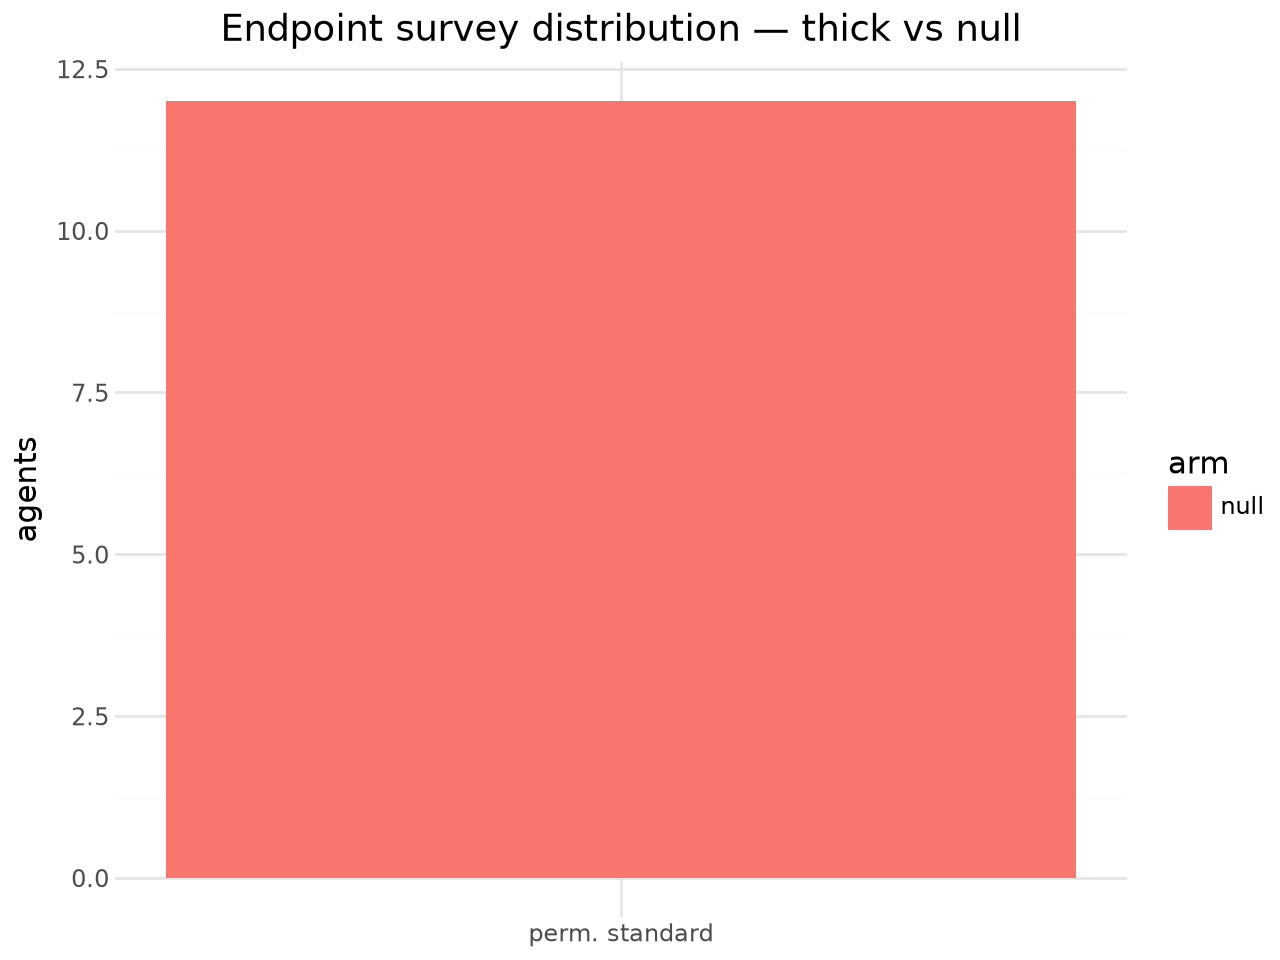

In [14]:
(ggplot(survey_df, aes('stance', 'n', fill='arm'))
 + geom_col(position=position_dodge())
 + labs(title='Endpoint survey distribution — thick vs null', x='', y='agents', fill='arm')
 + theme_minimal()) if not survey_df.empty else print('no survey rows to plot')

## Verdict

**DoD met.** The full R14–17 validation dashboard ran against the R16 null-model baseline (thin `NULL_PERSONA`, identical memories / topology / seed / temperature — persona content the only difference), 0 decide failures across both arms (12 agents × 5 ticks, `small_world` k=4 p=0.2). **R27 was read first (§1):** both arms speak every tick (abstain 0.00), use both poles (stance coverage 0.5), and keep high utterance uniqueness (thick 1.00 / null 0.97) with **no degeneracy flags** — so the §2–§4 numbers are genuine convergence, not an action-space artifact.

**The finding — persona depth protects the *voice*, not the *vote*.** Both arms converge to the **same stance** (dominant share → 1.00: everyone on permanent standard time by the endpoint; the morning-daylight majority in the cast wins out over the small-world graph). The categorical read *alone* would call both arms "fully converged." The embedding axis (the 5B addition) shows they are nothing alike:

| endpoint (tick 4) | thick | null |
|---|---|---|
| dominant share (categorical) | 1.00 | 1.00 |
| pairwise dispersion — voice (R14) | **0.204** | **0.121** |
| cluster count over 12 agents (R14) | **8** | **1** |
| mean identity drift from tick-0 baseline (R8) | **0.127** | **0.191** |

The thin/null personas **collapse into a single voice cluster** with steadily falling dispersion (5 → 1 clusters, 0.224 → 0.121 over the run) — the R7 "generic assistant voice" collapse, made quantitative. The thick personas **hold eight distinct voice-clusters among twelve agents** and higher dispersion throughout, and drift ~33% less from their own tick-0 voices. Value/disposition anchoring (R7) measurably resists identity collapse — on the voice axis the categorical metric is blind to. (The drift-probe `distance_to_centroid` is similar across arms, ~0.08 vs ~0.075: when each agent is re-asked the question *in isolation* the answers cluster similarly; it is the *in-conversation* SPEAK voice, §2/§3, where the thick arm stays diverse. The strong R8 signal is drift-from-baseline, not centroid spread.)

**R9 confirmed in the same run.** Thick personas did **not** prevent stance consensus — the population still converged collectively onto one option despite per-agent anchors. Persona diversity is necessary but not sufficient (R9): it preserved *how* agents spoke, not *what* they concluded, which the topology/memory dynamics drove to consensus (as P4 predicted for exposure). The two metric axes disagreeing is precisely the point — divergence is multi-dimensional, and a single number would have hidden the split.

**Answering the spike** (*what minimum persona content prevents identity collapse over N ticks?*): value + disposition anchors are **sufficient to prevent voice collapse** over 5 ticks at N=12 — the thin baseline collapsed to one voice, the thick set held eight, with lower per-agent drift. **Stance collapse is a separate, dynamics-driven phenomenon the persona layer alone does not stop** — that lever is topology/exchange volume (P4), not identity.

**Scope honesty.** Drift is baseline→endpoint (two points); a per-tick drift *trajectory* needs a `Simulation` step API (future). The thick endpoint *survey* (§5) hit the intermittent Qwen3 whitespace-blob quirk and was skipped by the notebook's guard — its endpoint is covered by the log-derived §3 summary (dom share 1.00), and the null survey confirmed unanimity directly; hardening the Layer-5 `run_survey` fan-out against that quirk is a P7 (survey-subsystem maturity) item. Cluster count is threshold-dependent (0.15, logged per R17), but the thick-vs-null gap (8 vs 1) is far too large to be an artifact of the exact value.
